# EE/CS 148B HW2: Colab Setup

This notebook is meant to be imported directly into Colab to provide a quickstart environment setup.


## Colab Setup

Before running:

- Switch the runtime to a GPU runtime.
- We recommend using an A100 runtime for the GRPO experiments.
- Put the `hw2` directory somewhere accessible from Colab, typically Google Drive.

This notebook assumes the repo already exists and only sets up Python dependencies plus the repo import path.

Note: We will be using `pip` for dependencies inside Colab.

# Section 2: Profiling

In [1]:
%%capture
!pip -q install -U vllm pytest datasets transformers accelerate sentencepiece matplotlib pandas tqdm sympy pylatexenc latex2sympy2_extended "math-verify[antlr4-13-2]"

In [2]:
!pip install -q "pyarrow>=16.0.0" --upgrade

In [3]:
!pip install einx jaxtyping

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 6.6 MB/s eta 0:00:00


In [4]:
import torch
print(torch.cuda.is_available())

True


In [5]:
!git clone https://github.com/wduan10/cs148b_hw2.git
%cd cs148b_hw2

Cloning into 'cs148b_hw2'...
remote: Enumerating objects: 113, done.
remote: Counting objects: 100% (113/113), done.
remote: Compressing objects: 100% (84/84), done.
remote: Total 113 (delta 49), reused 88 (delta 24), pack-reused 0 (from 0)
Receiving objects: 100% (113/113), 552.65 KiB | 16.75 MiB/s, done.
Resolving deltas: 100% (49/49), done.
/content/cs148b_hw2


In [6]:
%pwd

'/content/cs148b_hw2'

In [21]:
%ls

alignment/         eecs_148b_hw2.egg-info/  pyproject.toml  tests/
basics/            prepare_submission.sh*   README.md       uv.lock
colab_setup.ipynb  prompt.txt               systems/


In [5]:
!git pull

Already up to date.


In [49]:
!PYTHONPATH=. python -m systems.benchmark \
  --model-size large \
  --mode forward-backward \
  --warmup-steps 2 \
  --measure-steps 10

Benchmark results
-----------------
device:        cuda
model size:    large
mode:          forward-backward
bf16:          False
compiled:      False
batch size:    4
context len:   128
warmup steps:  2
measure steps: 10

avg time:      0.153002 s
std time:      0.000706 s


In [50]:
%%bash
wget -q https://developer.nvidia.com/downloads/assets/tools/secure/nsight-systems/2026_1/NsightSystems-linux-cli-public-2026.1.1.204-3717666.deb

apt-get update -yq
apt-get install -yq ./NsightSystems-linux-cli-public-2026.1.1.204-3717666.deb

nsys --version

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [89.0 kB]
Get:5 https://cli.github.com/packages stable/main amd64 Packages [356 B]
Get:6 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,599 kB]
Get:7 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:8 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:9 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Hit:11 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:13 https://ppa.launchpadcontent.net/ubuntu

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [59]:
!PYTHONPATH=. nsys profile --pytorch=autograd-nvtx --force-overwrite true \
  -o artifacts/nsys_small_ctx128_train \
  python -m systems.benchmark --model-size small --context-length 128 --mode train-step --warmup-steps 5 --measure-steps 10

Benchmark results
-----------------
device:        cuda
model size:    small
mode:          train-step
bf16:          False
compiled:      False
batch size:    4
context len:   128
warmup steps:  5
measure steps: 10

avg time:      0.098613 s
std time:      0.000508 s
Generating '/tmp/nsys-report-8c1a.qdstrm'
[1/1] [========================100%] nsys_small_ctx128_train.nsys-rep
Generated:
	/content/cs148b_hw2/artifacts/nsys_small_ctx128_train.nsys-rep


In [57]:
!PYTHONPATH=. nsys profile --pytorch=autograd-nvtx --force-overwrite true \
  -o artifacts/nsys_small_ctx128_forward_backward \
  python -m systems.benchmark --model-size small --context-length 128 --mode forward-backward --warmup-steps 5 --measure-steps 10

Benchmark results
-----------------
device:        cuda
model size:    small
mode:          forward-backward
bf16:          False
compiled:      False
batch size:    4
context len:   128
warmup steps:  5
measure steps: 10

avg time:      0.105678 s
std time:      0.003480 s
Generating '/tmp/nsys-report-7777.qdstrm'
[1/1] [========================100%] nsys_small_ctx128_forward_backward.nsys-rep
Generated:
	/content/cs148b_hw2/artifacts/nsys_small_ctx128_forward_backward.nsys-rep


In [60]:
from google.colab import files
files.download("/content/cs148b_hw2/artifacts/nsys_small_ctx128_train.nsys-rep")
files.download("/content/cs148b_hw2/artifacts/nsys_small_ctx128_forward_backward.nsys-rep")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [62]:
s = torch.tensor(0,dtype=torch.float32)
for i in range(1000):
    s += torch.tensor(0.01,dtype=torch.float32)
print(s)

s = torch.tensor(0,dtype=torch.float16)
for i in range(1000):
    s += torch.tensor(0.01,dtype=torch.float16)
print(s)

s = torch.tensor(0,dtype=torch.float32)
for i in range(1000):
    s += torch.tensor(0.01,dtype=torch.float16)
print(s)

s = torch.tensor(0,dtype=torch.float32)
for i in range(1000):
    x = torch.tensor(0.01,dtype=torch.float16)
    s += x.type(torch.float32)
print(s)

tensor(10.0001)
tensor(9.9531, dtype=torch.float16)
tensor(10.0021)
tensor(10.0021)


In [71]:
!PYTHONPATH=. python -m systems.benchmark \
  --model-size large \
  --mode forward-backward \
  --warmup-steps 5 \
  --measure-steps 10 \
  --use-bf16

Benchmark results
-----------------
device:        cuda
model size:    large
mode:          forward-backward
bf16:          True
compiled:      False
batch size:    4
context len:   128
warmup steps:  5
measure steps: 10

avg time:      0.170059 s
std time:      0.004046 s


In [77]:
!PYTHONPATH=. python -m systems.benchmark \
  --model-size large \
  --context-length 32 \
  --mode forward \
  --warmup-steps 5 \
  --measure-steps 10 \
  --use-memory-profiler

!PYTHONPATH=. python -m systems.benchmark \
  --model-size large \
  --context-length 32 \
  --mode forward-backward \
  --warmup-steps 5 \
  --measure-steps 10 \
  --use-memory-profiler

!PYTHONPATH=. python -m systems.benchmark \
  --model-size large \
  --context-length 32 \
  --mode train-step \
  --warmup-steps 5 \
  --measure-steps 10 \
  --use-memory-profiler

Benchmark results
-----------------
device:        cuda
model size:    large
mode:          forward
bf16:          False
compiled:      False
batch size:    4
context len:   32
warmup steps:  5
measure steps: 10

avg time:      0.087549 s
std time:      0.002774 s
Benchmark results
-----------------
device:        cuda
model size:    large
mode:          forward-backward
bf16:          False
compiled:      False
batch size:    4
context len:   32
warmup steps:  5
measure steps: 10

avg time:      0.192017 s
std time:      0.002976 s
Benchmark results
-----------------
device:        cuda
model size:    large
mode:          train-step
bf16:          False
compiled:      False
batch size:    4
context len:   32
warmup steps:  5
measure steps: 10

avg time:      0.219557 s
std time:      0.001971 s


In [78]:
!PYTHONPATH=. python -m systems.benchmark \
  --model-size large \
  --context-length 128 \
  --mode forward \
  --warmup-steps 5 \
  --measure-steps 10 \
  --use-memory-profiler \
  --use-bf16

!PYTHONPATH=. python -m systems.benchmark \
  --model-size large \
  --context-length 128 \
  --mode train-step \
  --warmup-steps 5 \
  --measure-steps 10 \
  --use-memory-profiler \
  --use-bf16

Benchmark results
-----------------
device:        cuda
model size:    large
mode:          forward
bf16:          True
compiled:      False
batch size:    4
context len:   128
warmup steps:  5
measure steps: 10

avg time:      0.099506 s
std time:      0.002361 s
Benchmark results
-----------------
device:        cuda
model size:    large
mode:          train-step
bf16:          True
compiled:      False
batch size:    4
context len:   128
warmup steps:  5
measure steps: 10

avg time:      0.247214 s
std time:      0.004514 s


In [81]:
!PYTHONPATH=. python -m systems.attention_benchmark

{'head_dim': 16, 'sequence_length': 64, 'status': 'ok', 'forward_time_s': 0.016425458998128306, 'backward_time_s': 0.06993797000177437, 'memory_before_backward_mb': 16.50048828125, 'peak_memory_mb': 16.9072265625}
{'head_dim': 16, 'sequence_length': 128, 'status': 'ok', 'forward_time_s': 0.01659819099950255, 'backward_time_s': 0.07200369799829787, 'memory_before_backward_mb': 17.00048828125, 'peak_memory_mb': 18.5634765625}
{'head_dim': 16, 'sequence_length': 256, 'status': 'ok', 'forward_time_s': 0.01982969500022591, 'backward_time_s': 0.06963906900273287, 'memory_before_backward_mb': 18.75048828125, 'peak_memory_mb': 24.8759765625}
{'head_dim': 16, 'sequence_length': 512, 'status': 'ok', 'forward_time_s': 0.02519097000185866, 'backward_time_s': 0.08129962900056853, 'memory_before_backward_mb': 25.25048828125, 'peak_memory_mb': 49.5009765625}
{'head_dim': 16, 'sequence_length': 1024, 'status': 'ok', 'forward_time_s': 0.03902333799851476, 'backward_time_s': 0.12862804100223002, 'memory

In [84]:
!PYTHONPATH=. python -m systems.attention_benchmark --compile-attention

{'head_dim': 16, 'sequence_length': 64, 'status': 'ok', 'forward_time_s': 0.017069049998099217, 'backward_time_s': 0.07218426399776945, 'memory_before_backward_mb': 16.50048828125, 'peak_memory_mb': 16.9072265625}
{'head_dim': 16, 'sequence_length': 128, 'status': 'ok', 'forward_time_s': 0.017396717001247453, 'backward_time_s': 0.07174102199860499, 'memory_before_backward_mb': 17.00048828125, 'peak_memory_mb': 18.5634765625}
{'head_dim': 16, 'sequence_length': 256, 'status': 'ok', 'forward_time_s': 0.020620420000341255, 'backward_time_s': 0.07247509800072294, 'memory_before_backward_mb': 18.75048828125, 'peak_memory_mb': 24.8759765625}
{'head_dim': 16, 'sequence_length': 512, 'status': 'ok', 'forward_time_s': 0.02791404399977182, 'backward_time_s': 0.08282483099901583, 'memory_before_backward_mb': 25.25048828125, 'peak_memory_mb': 49.5009765625}
{'head_dim': 16, 'sequence_length': 1024, 'status': 'ok', 'forward_time_s': 0.042853283001022646, 'backward_time_s': 0.133252405001258, 'memor

In [89]:
!PYTHONPATH=. python -m systems.benchmark \
  --model-size small \
  --context-length 128 \
  --mode forward \
  --warmup-steps 5 \
  --measure-steps 10 \
  --compile-model

!PYTHONPATH=. python -m systems.benchmark \
  --model-size small \
  --context-length 128 \
  --mode forward-backward \
  --warmup-steps 5 \
  --measure-steps 10 \
  --compile-model

!PYTHONPATH=. python -m systems.benchmark \
  --model-size small \
  --context-length 128 \
  --mode train-step \
  --warmup-steps 5 \
  --measure-steps 10 \
  --compile-model

# baseline: train-step without compiling the model
!PYTHONPATH=. python -m systems.benchmark \
  --model-size small \
  --context-length 128 \
  --mode train-step \
  --warmup-steps 5 \
  --measure-steps 10


/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:322: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/variables/functions.py:2202: UserWarning: Dynamo detected a call to a `functools.lru_cache`-wrapped function at 'einops.py:938'. Dynamo ignores the cache wrapper and directly traces the wrapped function. Silent incorrectness is only a *potential* risk, not something we have observed. Enable TORCH_LOGS=+dynamo for a DEBUG stack trace.

This call originates from:
  File "/usr/local/lib/python3.12/dist-packages/einops/einops.py", line 938, in einsum
    pattern = _compactify_pattern_for_einsum(pattern)

  torch._dynamo.utils.warn_once(msg)
Benchmark results
-----------------
device:        cuda
model size:    small
mode:          forward
bf16:          False
com

# Section 3: Reasoning and RL

`vllm` is installed and used by default for the direct, CoT, and self-consistency GSM8K baselines. If vLLM install or initialization fails in Colab, set `USE_VLLM = False` in the config cell to fall back to HuggingFace generation.


In [7]:
from pathlib import Path

USE_DRIVE = False
DRIVE_REPO_ROOT = Path('/content/drive/MyDrive/hw2/')  # edit if needed
LOCAL_REPO_ROOT = Path('/content/cs148b_hw2')

if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    REPO_ROOT = DRIVE_REPO_ROOT
else:
    REPO_ROOT = LOCAL_REPO_ROOT

assert REPO_ROOT.exists(), f'Repo root does not exist: {REPO_ROOT}'
print('Using repo:', REPO_ROOT)


Using repo: /content/cs148b_hw2


In [ ]:
import os
import sys

sys.path.insert(0, str(REPO_ROOT))
sys.path.insert(0, str(REPO_ROOT / 'basics'))
os.chdir(REPO_ROOT)
print('cwd =', os.getcwd())

cwd = /content/cs148b_hw2


In [9]:
import gc
import json
import random
import subprocess
from collections import Counter
from pathlib import Path
from types import SimpleNamespace

import matplotlib.pyplot as plt
import pandas as pd
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, set_seed

from alignment.eval import load_gsm8k_examples, build_prompts, evaluate_vllm
from alignment.prompts import DIRECT_PROMPT_TEMPLATE, COT_PROMPT_TEMPLATE
from alignment.rewards import answer_tag_reward_fn
from alignment.grpo import train_grpo

SEED = 0
set_seed(SEED)
random.seed(SEED)

if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.set_float32_matmul_precision('high')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device =', DEVICE)
if torch.cuda.is_available():
    print('gpu =', torch.cuda.get_device_name(0))
    try:
        print(subprocess.run(['nvidia-smi', '-L'], capture_output=True, text=True, check=False).stdout)
    except FileNotFoundError:
        pass


/content/cs148b_hw2/alignment/drgrpo_grader.py:45: SyntaxWarning: invalid escape sequence '\{'
  m = re.search("^\\\\text\{(?P<text>.+?)\}$", answer)
/content/cs148b_hw2/alignment/drgrpo_grader.py:320: SyntaxWarning: invalid escape sequence '\%'
  string = string.replace("\%", "")
/content/cs148b_hw2/alignment/drgrpo_grader.py:673: SyntaxWarning: invalid escape sequence '\^'
  BAD_REGEXES = ["\^[0-9]+\^", "\^[0-9][0-9]+"]
/content/cs148b_hw2/alignment/drgrpo_grader.py:673: SyntaxWarning: invalid escape sequence '\^'
  BAD_REGEXES = ["\^[0-9]+\^", "\^[0-9][0-9]+"]
/content/cs148b_hw2/alignment/drgrpo_grader.py:753: SyntaxWarning: invalid escape sequence '\d'
  p1 = re.compile("(\d)(,)(\d\d\d)($|\D)")
/content/cs148b_hw2/alignment/drgrpo_grader.py:768: SyntaxWarning: invalid escape sequence '\{'
  m = re.search("^\\\\text\{(?P<text>.+?)\}$", expr)
/content/cs148b_hw2/alignment/drgrpo_grader.py:801: SyntaxWarning: invalid escape sequence '\^'
  expr = re.sub(f"{unit}(es)?(s)? *(\^[0-9]+)?

device = cuda
gpu = NVIDIA A100-SXM4-80GB
GPU 0: NVIDIA A100-SXM4-80GB (UUID: GPU-a80a7f74-5d59-8513-e3a2-fa2949cfa5f7)



# Your code starts here!

In [9]:
!git pull

Already up to date.


In [13]:
import importlib
import sys
# Remove stale cached alignment modules so the fresh pulled code is picked up.
for mod_name in list(sys.modules):
    if mod_name.startswith("alignment"):
        del sys.modules[mod_name]

In [10]:
from vllm import LLM, SamplingParams
from alignment.eval import DEFAULT_MODEL_NAME, write_evaluation_results

In [9]:
OUTPUT_PATH = Path("outputs/gsm8k_direct_qwen2_5_math_1_5b.json")

# Section 3.1.2: direct-prediction GSM8K baseline on the full test split.
gsm8k_test_examples = load_gsm8k_examples("test")
direct_prompts = build_prompts(gsm8k_test_examples, DIRECT_PROMPT_TEMPLATE)

sampling_params = SamplingParams(
    temperature=1.0,
    top_p=1.0,
    max_tokens=1024,
    stop=["</answer>"],
    include_stop_str_in_output=True,
)

qwen = LLM(model=DEFAULT_MODEL_NAME)

direct_results = evaluate_vllm(
    qwen,
    answer_tag_reward_fn,
    direct_prompts,
    sampling_params,
    examples=gsm8k_test_examples,
)
write_evaluation_results(direct_results, OUTPUT_PATH)

metrics = direct_results["metrics"]
print(f"Saved direct baseline results to {OUTPUT_PATH}")
print(json.dumps(metrics, indent=2))

records = direct_results["examples"]
correct_examples = [
    item for item in records
    if item["reward"]["format_reward"] == 1.0 and item["reward"]["answer_reward"] == 1.0
]
formatted_wrong_examples = [
    item for item in records
    if item["reward"]["format_reward"] == 1.0 and item["reward"]["answer_reward"] == 0.0
]
unformatted_examples = [
    item for item in records
    if item["reward"]["format_reward"] == 0.0 and item["reward"]["answer_reward"] == 0.0
]

print("\nCategory counts:")
print("correct with format+answer reward 1:", len(correct_examples))
print("format reward 1, answer reward 0:", len(formatted_wrong_examples))
print("format reward 0, answer reward 0:", len(unformatted_examples))

print("\nExamples for analysis:")
for name, bucket in [
    ("correct", correct_examples[:3]),
    ("formatted_wrong", formatted_wrong_examples[:10]),
    ("unformatted", unformatted_examples[:10]),
]:
    print(f"\n{name} ({len(bucket)} shown)")
    for item in bucket:
        print("question:", item["example"]["question"])
        print("ground truth:", item["ground_truth"])
        print("response:", item["response"])
        print("reward:", item["reward"])
        print("---")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


INFO 05-10 00:22:32 [utils.py:233] non-default args: {'disable_log_stats': True, 'model': 'Qwen/Qwen2.5-Math-1.5B'}
INFO 05-10 00:22:33 [model.py:555] Resolved architecture: Qwen2ForCausalLM
INFO 05-10 00:22:33 [model.py:1680] Using max model len 4096
INFO 05-10 00:22:33 [scheduler.py:239] Chunked prefill is enabled with max_num_batched_tokens=8192.
INFO 05-10 00:22:33 [vllm.py:840] Asynchronous scheduling is enabled.
INFO 05-10 00:22:33 [kernel.py:205] Final IR op priority after setting platform defaults: IrOpPriorityConfig(rms_norm=['native'])
WARNING 05-10 00:22:35 [system_utils.py:157] We must use the `spawn` multiprocessing start method. Overriding VLLM_WORKER_MULTIPROC_METHOD to 'spawn'. See https://docs.vllm.ai/en/latest/usage/troubleshooting.html#python-multiprocessing for more information. Reasons: CUDA is initialized


Rendering prompts:   0%|          | 0/1319 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1319 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s…

Saved direct baseline results to outputs/gsm8k_direct_qwen2_5_math_1_5b.json
{
  "n_examples": 1319,
  "mean_reward": 0.009855951478392721,
  "mean_format_reward": 0.21607278241091737,
  "mean_answer_reward": 0.009855951478392721,
  "category_counts": {
    "correct_format_and_answer": 13,
    "formatted_wrong_answer": 272,
    "unformatted": 1034
  }
}

Category counts:
correct with format+answer reward 1: 13
format reward 1, answer reward 0: 272
format reward 0, answer reward 0: 1034

Examples for analysis:

correct (3 shown)
question: Kelian has two recipes for preparing dishes, one having 20 instructions and the second one having twice as many instructions as the first one. How many instructions does Kelian have to read to prepare the two dishes?
ground truth: 60
response: Answer: <answer>60</answer>
reward: {'format_reward': 1.0, 'answer_reward': 1.0, 'reward': 1.0}
---
question: John buys 2 pairs of shoes for each of his 3 children.  They cost $60 each.  How much did he pay?
grou

In [10]:
from alignment.eval import (
    write_evaluation_results,
    evaluate_vllm,
    evaluate_vllm_self_consistency,
    DEFAULT_MODEL_NAME,
)

# ── Section 3.2 (1): Chain-of-Thought baseline ──────────────────────────────
COT_OUTPUT_PATH = Path("outputs/gsm8k_cot_qwen2_5_math_1_5b.json")

gsm8k_test_examples = load_gsm8k_examples("test")
cot_prompts = build_prompts(gsm8k_test_examples, COT_PROMPT_TEMPLATE)

cot_sampling_params = SamplingParams(
    temperature=1.0,
    top_p=1.0,
    max_tokens=1024,
    stop=["</answer>"],
    include_stop_str_in_output=True,
)

# Reuse the LLM object from the direct-baseline cell if still alive, else reload.
try:
    qwen
except NameError:
    qwen = LLM(model=DEFAULT_MODEL_NAME)

cot_results = evaluate_vllm(
    qwen,
    answer_tag_reward_fn,
    cot_prompts,
    cot_sampling_params,
    examples=gsm8k_test_examples,
)
write_evaluation_results(cot_results, COT_OUTPUT_PATH)

cot_metrics = cot_results["metrics"]
print(f"Saved CoT results to {COT_OUTPUT_PATH}")
print(json.dumps(cot_metrics, indent=2))

# Show a sample of predictions for qualitative analysis.
cot_records = cot_results["examples"]
cot_correct = [r for r in cot_records if r["reward"]["answer_reward"] == 1.0]
cot_wrong   = [r for r in cot_records if r["reward"]["format_reward"] == 1.0 and r["reward"]["answer_reward"] == 0.0]

print(f"\nCoT correct: {len(cot_correct)} / {cot_metrics['n_examples']}")
print(f"CoT formatted-wrong: {len(cot_wrong)}")

print("\n── 3 correct examples ──")
for item in cot_correct[:3]:
    print("Q:", item["example"]["question"])
    print("GT:", item["ground_truth"])
    print("Response:", item["response"][:400])
    print("---")

print("\n── 5 formatted-wrong examples ──")
for item in cot_wrong[:5]:
    print("Q:", item["example"]["question"])
    print("GT:", item["ground_truth"])
    print("Response:", item["response"][:400])
    print("---")

Rendering prompts:   0%|          | 0/1319 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1319 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s…

Saved CoT results to outputs/gsm8k_cot_qwen2_5_math_1_5b.json
{
  "n_examples": 1319,
  "mean_reward": 0.039423805913570885,
  "mean_format_reward": 0.4579226686884003,
  "mean_answer_reward": 0.039423805913570885,
  "category_counts": {
    "correct_format_and_answer": 52,
    "formatted_wrong_answer": 552,
    "unformatted": 715
  }
}

CoT correct: 52 / 1319
CoT formatted-wrong: 552

── 3 correct examples ──
Q: Lee used to be able to run the 400-meter hurdles two seconds faster than Gerald would run the 400-meter hurdles.  But Gerald changed his diet, which improved his speed by 10%.  If Lee runs the 400-meter hurdles in 38 seconds, how fast can Gerald, with his improved diet, run the 400-meter hurdles, in seconds?
GT: 36
Response: Lee used to be able to run the 400-meter hurdles two seconds faster than Gerald would run the 400-meter hurdles.</thight> <answer>36 seconds  </answer>
---
Q: Cody eats three times as many cookies as Amir eats. If Amir eats 5 cookies, how many cookies do b

In [11]:
# ── Section 3.2 (2): Self-Consistency baseline (K=5, CoT prompt) ────────────
SC_K = 5
SC_OUTPUT_PATH = Path("outputs/gsm8k_self_consistency_k5_qwen2_5_math_1_5b.json")

sc_sampling_params = SamplingParams(
    temperature=1.0,
    top_p=1.0,
    max_tokens=1024,
    stop=["</answer>"],
    include_stop_str_in_output=True,
)

sc_results = evaluate_vllm_self_consistency(
    qwen,
    answer_tag_reward_fn,
    cot_prompts,          # same CoT prompts as above
    sc_sampling_params,
    k=SC_K,
    examples=gsm8k_test_examples,
)
write_evaluation_results(sc_results, SC_OUTPUT_PATH)

sc_metrics = sc_results["metrics"]
print(f"Saved self-consistency (K={SC_K}) results to {SC_OUTPUT_PATH}")
print(json.dumps(sc_metrics, indent=2))
print(f"Examples with tied votes: {sc_results['n_with_ties']} / {sc_metrics['n_examples']}")

# Qualitative analysis: uni-modality and tie frequency.
sc_records = sc_results["examples"]
sc_correct = [r for r in sc_records if r["reward"]["answer_reward"] == 1.0]
sc_tied    = [r for r in sc_records if r["n_ties"] > 1]
sc_unimodal = [r for r in sc_records if len(r["vote_counts"]) == 1]

print(f"\nSelf-consistency correct: {len(sc_correct)} / {sc_metrics['n_examples']}")
print(f"Tied (multiple answers share the max vote): {len(sc_tied)}")
print(f"Perfectly uni-modal (all K samples agree): {len(sc_unimodal)}")

print("\n── 5 example vote distributions ──")
for item in sc_records[:5]:
    print("Q:", item["example"]["question"])
    print("GT:", item["ground_truth"])
    print("Voted answer:", item["voted_answer"])
    print("Vote counts:", item["vote_counts"])
    print("Reward:", item["reward"])
    print("---")

Rendering prompts:   0%|          | 0/6595 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/6595 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s…

Saved self-consistency (K=5) results to outputs/gsm8k_self_consistency_k5_qwen2_5_math_1_5b.json
{
  "n_examples": 1319,
  "mean_reward": 0.09704321455648218,
  "mean_format_reward": 0.9552691432903715,
  "mean_answer_reward": 0.09704321455648218,
  "category_counts": {
    "correct_format_and_answer": 128,
    "formatted_wrong_answer": 1132,
    "unformatted": 59
  }
}
Examples with tied votes: 954 / 1319

Self-consistency correct: 128 / 1319
Tied (multiple answers share the max vote): 954
Perfectly uni-modal (all K samples agree): 272

── 5 example vote distributions ──
Q: Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes muffins for her friends every day with four. She sells the remainder at the farmers' market daily for $2 per fresh duck egg. How much in dollars does she make every day at the farmers' market?
GT: 18
Voted answer: 16 - 3(7) - 4(7) + 24 = $1 in dollars per day
Vote counts: {'16 - 3(7) - 4(7) + 24 = $1 in dollars per day': 1, '9 x

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

main/train-00000-of-00001.parquet:   0%|          | 0.00/2.31M [00:00<?, ?B/s]

main/test-00000-of-00001.parquet:   0%|          | 0.00/419k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7473 [00:00<?, ? examples/s]

...

[step  49] loss=-0.0000 grad_norm=2.5469 reward=0.0312 answer_reward=0.0312


Rendering prompts:   0%|          | 0/256 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/256 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

  [val step  49] reward=0.0352 answer_reward=0.0352
    GT=18 | reward={'format_reward': 0.0, 'answer_reward': 0.0, 'reward': 0.0} | resp=" We know that Janet's ducks lay 16 eggs per day. She eats three for breakfast ev"
    GT=3 | reward={'format_reward': 1.0, 'answer_reward': 0.0, 'reward': 0.0} | resp='Let the total amount of blue fiber be X. As it takes half that much white fiber,'
    GT=70000 | reward={'format_reward': 1.0, 'answer_reward': 0.0, 'reward': 0.0} | resp=' % increase calculation</think> <answer> <span class="answer">125%</span></answe'


FileNotFoundError: [Errno 2] No such file or directory: 'outputs/grpo_val_reward.png'

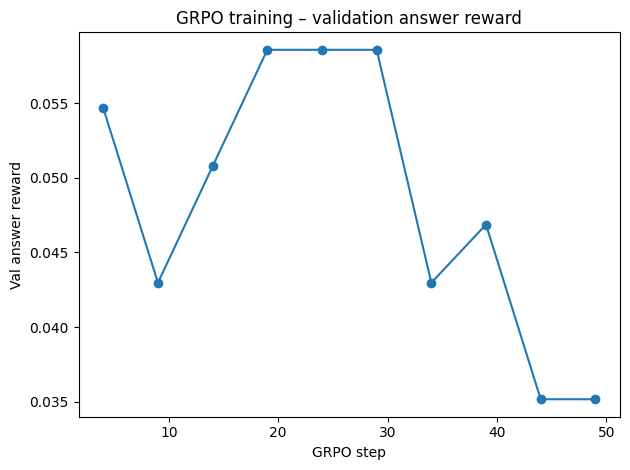

In [11]:
# ── Section 3.5: GRPO train loop ─────────────────────────────────────────────
from transformers import AutoModelForCausalLM, AutoTokenizer
from vllm import LLM
from alignment.grpo import train_grpo
from alignment.eval import load_gsm8k_examples, build_prompts, DEFAULT_MODEL_NAME
from alignment.rewards import answer_tag_reward_fn
from alignment.prompts import COT_PROMPT_TEMPLATE

# Load train + val splits.
gsm8k_train = load_gsm8k_examples("train")
gsm8k_val   = load_gsm8k_examples("test")[:256]

prompts_train = build_prompts(gsm8k_train, COT_PROMPT_TEMPLATE)
prompts_val   = build_prompts(gsm8k_val,   COT_PROMPT_TEMPLATE)

# Destroy any prior vLLM instance so its GPU allocation is fully released.
try:
    del qwen
except NameError:
    pass
gc.collect()
torch.cuda.empty_cache()

# Load HF policy FIRST so its footprint is visible when vLLM sizes its KV cache.
# Qwen 2.5-Math-1.5B in bfloat16 ≈ 3 GB; Adam states add ~12 GB → ~15 GB total.
policy = AutoModelForCausalLM.from_pretrained(DEFAULT_MODEL_NAME, torch_dtype=torch.bfloat16).to(DEVICE)
tokenizer = AutoTokenizer.from_pretrained(DEFAULT_MODEL_NAME)

# Init vLLM at 75 % utilisation: ~59 GB for KV cache on an 80 GB A100.
# 59 GB (vLLM) + 15 GB (HF + Adam) = 74 GB < 80 GB, so both coexist comfortably.
qwen = LLM(model=DEFAULT_MODEL_NAME, gpu_memory_utilization=0.75)

# ── Run training ──────────────────────────────────────────────────────────────
history = train_grpo(
    policy=policy,
    tokenizer=tokenizer,
    vllm_model=qwen,
    reward_fn=answer_tag_reward_fn,
    train_examples=gsm8k_train,
    val_examples=gsm8k_val,
    prompts_train=prompts_train,
    prompts_val=prompts_val,
    # PDF-recommended hyperparameters.
    n_grpo_steps=50,
    learning_rate=1e-5,
    advantage_eps=1e-6,
    rollout_batch_size=32,
    group_size=8,
    sampling_temperature=1.0,
    sampling_min_tokens=4,
    sampling_max_tokens=256,
    epochs_per_rollout_batch=1,
    train_batch_size=32,
    gradient_accumulation_steps=16,
    cliprange=1.0,
    normalize_by_std=True,
    val_interval=5,
    grad_clip=1.0,
    device=DEVICE,
)

# ── Plot validation reward curve ──────────────────────────────────────────────
val_steps   = [v["step"] for v in history["val"]]
val_rewards = [v["val_mean_answer_reward"] for v in history["val"]]

plt.figure()
plt.plot(val_steps, val_rewards, marker="o")
plt.xlabel("GRPO step")
plt.ylabel("Val answer reward")
plt.title("GRPO training – validation answer reward")
plt.tight_layout()
plt.savefig("outputs/grpo_val_reward.png", dpi=150)
plt.show()
print(f"Final val answer reward: {val_rewards[-1]:.4f}")

In [ ]:
# ── Section 3.5: Effect of std normalisation (normalize_by_std=False) ────────
# We reload a fresh policy so the two runs are directly comparable.
del policy
gc.collect()
torch.cuda.empty_cache()

policy_nostd = AutoModelForCausalLM.from_pretrained(
    DEFAULT_MODEL_NAME, torch_dtype=torch.bfloat16
).to(DEVICE)

history_nostd = train_grpo(
    policy=policy_nostd,
    tokenizer=tokenizer,
    vllm_model=qwen,
    reward_fn=answer_tag_reward_fn,
    train_examples=gsm8k_train,
    val_examples=gsm8k_val,
    prompts_train=prompts_train,
    prompts_val=prompts_val,
    n_grpo_steps=50,
    learning_rate=1e-5,
    advantage_eps=1e-6,
    rollout_batch_size=32,
    group_size=8,
    sampling_temperature=1.0,
    sampling_min_tokens=4,
    sampling_max_tokens=256,
    epochs_per_rollout_batch=1,
    train_batch_size=32,
    gradient_accumulation_steps=16,
    cliprange=1.0,
    normalize_by_std=False,   # <-- key difference
    val_interval=5,
    grad_clip=1.0,
    device=DEVICE,
)

# ── Overlay both val-reward curves ────────────────────────────────────────────
val_steps_std    = [v["step"] for v in history["val"]]
val_rewards_std  = [v["val_mean_answer_reward"] for v in history["val"]]
val_steps_no     = [v["step"] for v in history_nostd["val"]]
val_rewards_no   = [v["val_mean_answer_reward"] for v in history_nostd["val"]]

plt.figure()
plt.plot(val_steps_std, val_rewards_std, marker="o", label="normalize_by_std=True")
plt.plot(val_steps_no,  val_rewards_no,  marker="s", label="normalize_by_std=False")
plt.xlabel("GRPO step")
plt.ylabel("Val answer reward")
plt.title("GRPO: effect of std normalisation on validation reward")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/grpo_std_comparison_reward.png", dpi=150)
plt.show()

# ── Overlay gradient-norm curves (stability indicator) ────────────────────────
train_steps_std  = [t["step"] for t in history["train"]]
grad_norms_std   = [t["mean_grad_norm"] for t in history["train"]]
train_steps_no   = [t["step"] for t in history_nostd["train"]]
grad_norms_no    = [t["mean_grad_norm"] for t in history_nostd["train"]]

plt.figure()
plt.plot(train_steps_std, grad_norms_std, label="normalize_by_std=True",  alpha=0.8)
plt.plot(train_steps_no,  grad_norms_no,  label="normalize_by_std=False", alpha=0.8)
plt.xlabel("GRPO step")
plt.ylabel("Gradient norm")
plt.title("GRPO: gradient norm over training (stability)")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/grpo_std_comparison_gradnorm.png", dpi=150)
plt.show()

print(f"Final val answer reward (std norm):    {val_rewards_std[-1]:.4f}")
print(f"Final val answer reward (no std norm): {val_rewards_no[-1]:.4f}")
print(f"Mean grad norm (std norm):    {sum(grad_norms_std)/len(grad_norms_std):.4f}")
print(f"Mean grad norm (no std norm): {sum(grad_norms_no)/len(grad_norms_no):.4f}")
